# Exploratory Analysis: Insufficient Physical Activity (WHO)

**Author:** Karin Pietruska  
**Date:** 15 November 2025


## 1. Purpose and analytical questions

This notebook analyses WHO Global Health Observatory estimates of **age-standardized insufficient physical activity among adults aged 18+ years** (indicator `NCD_PAA`). Values are prevalence estimates in percent, with 95% confidence intervals. Age-standardization supports comparison across countries with different age structures; these are not crude (unadjusted) prevalence rates.

The processed table comes from `01_data_preparation_who_physical_inactivity.ipynb`.

**Questions**

1. How was age-standardized insufficient physical activity distributed across countries in **2022**?
2. How did male and female country-level estimates differ in 2022?
3. How did WHO regions compare in 2022?
4. How did country-level prevalence vary geographically in 2022?
5. How did the female–male difference in country-level estimates vary geographically in 2022?
6. How did the **WHO global estimate** change from 2000 to 2022?

**How results are framed**

- Cross-sectional country tables and distribution plots use **2022** only (`spatial_type == "Country"`). Each country contributes one observation per sex category.
- Country-level means are **unweighted** (each country counts equally). They are **not** the WHO global population-level estimate.
- The term **WHO global estimate** is reserved for rows with `spatial_type == "Global"`.
- Country maps use Natural Earth 110m boundaries joined on ISO 3166-1 alpha-3. Small states without a 110m polygon are listed, not invented.


## 2. Imports and project paths


In [53]:
from pathlib import Path
import sys

import math

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from IPython.display import display


In [54]:
def find_project_root() -> Path:
    """Return the repository root containing the processed analysis table."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "who_physical_inactivity_clean.csv").exists():
            return candidate
        if (candidate / "environment.yml").exists() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the repository "
        "(working directory: repo root or notebooks/)."
    )


PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_CSV = DATA_PROCESSED / "who_physical_inactivity_clean.csv"
COUNTRY_CSV = DATA_RAW / "who_ncd_paa_country.csv"
NE_COUNTRIES = (
    DATA_EXTERNAL
    / "ne_110m_admin_0_countries"
    / "ne_110m_admin_0_countries.shp"
)

if not PROCESSED_CSV.exists():
    raise FileNotFoundError(
        f"Processed dataset not found at {PROCESSED_CSV.relative_to(PROJECT_ROOT)}. "
        "Run notebooks/01_data_preparation_who_physical_inactivity.ipynb first."
    )
if not NE_COUNTRIES.exists():
    raise FileNotFoundError(
        f"Natural Earth boundaries not found at {NE_COUNTRIES.relative_to(PROJECT_ROOT)}."
    )

print("Processed data:", PROCESSED_CSV.relative_to(PROJECT_ROOT))
print("Country-name CSV:", COUNTRY_CSV.relative_to(PROJECT_ROOT))
print("Natural Earth:", NE_COUNTRIES.relative_to(PROJECT_ROOT))
print("Figures directory:", FIGURES_DIR.relative_to(PROJECT_ROOT))


Processed data: data/processed/who_physical_inactivity_clean.csv
Country-name CSV: data/raw/who_ncd_paa_country.csv
Natural Earth: data/external/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp
Figures directory: figures


In [55]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE_SEX = {
    "Male": "#2E86AB",
    "Female": "#E07A5F",
    "Both sexes": "#81B29A",
}

FIGSIZE = (8.5, 5.0)


def save_figure(filename: str) -> Path:
    """Save the current Matplotlib figure into figures/ at 300 dpi."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")
    return path


## 3. Load and validate processed data


In [56]:
EXPECTED_COLUMNS = [
    "who_id", "spatial_type", "country_code", "region",
    "sex", "prevalence", "ci_low", "ci_high", "year",
]

df = pd.read_csv(PROCESSED_CSV)
missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Processed file is missing columns: {missing}")

print(f"Rows: {len(df):,}")
print("Spatial levels:")
print(df["spatial_type"].value_counts().to_string())
print(f"\nYears: {int(df['year'].min())}–{int(df['year'].max())}")
print(
    "Country codes (country-level rows):",
    df.loc[df["spatial_type"] == "Country", "country_code"].nunique(),
)
df.head()


Rows: 14,214
Spatial levels:
spatial_type
Country                    13455
Region                       414
World Bank Income Group      276
Global                        69

Years: 2000–2022
Country codes (country-level rows): 195


,who_id,spatial_type,country_code,region,sex,prevalence,ci_low,ci_high,year
0,951007,Region,WPR,NaN,Male,23.225080,19.813980,26.825520,2010
1,951833,Country,QAT,Eastern Mediterranean,Male,46.199745,33.522572,58.878918,2010
2,951955,Country,BRN,Western Pacific,Female,36.193363,21.513872,52.714764,2019
3,952621,Country,BHR,Eastern Mediterranean,Male,34.262978,15.071355,59.493984,2016
4,952711,Country,MLI,Africa,Both sexes,33.919476,21.537233,47.789452,2010


## 4. Analysis subsets

Reusable slices for the rest of the notebook. Country comparisons use 2022; the WHO global series uses all years 2000–2022.


In [57]:
df_country_2022_both = df.loc[
    (df["spatial_type"] == "Country")
    & (df["sex"] == "Both sexes")
    & (df["year"] == 2022)
].copy()

df_country_2022_sex = df.loc[
    (df["spatial_type"] == "Country")
    & (df["sex"].isin(["Male", "Female"]))
    & (df["year"] == 2022)
].copy()

df_global_both = (
    df.loc[
        (df["spatial_type"] == "Global")
        & (df["sex"] == "Both sexes")
    ]
    .sort_values("year")
    .copy()
)

print(
    f"Country, both sexes, 2022: {len(df_country_2022_both)} rows "
    f"({df_country_2022_both['country_code'].nunique()} countries)"
)
print(
    f"Country, male/female, 2022: {len(df_country_2022_sex)} rows "
    f"({df_country_2022_sex['country_code'].nunique()} countries)"
)
print(
    f"WHO global estimate, both sexes: {len(df_global_both)} yearly observations "
    f"({int(df_global_both['year'].min())}–{int(df_global_both['year'].max())})"
)


Country, both sexes, 2022: 195 rows (195 countries)
Country, male/female, 2022: 390 rows (195 countries)
WHO global estimate, both sexes: 23 yearly observations (2000–2022)


## 5. Descriptive statistics for 2022

The tables below summarize **unweighted** country-level estimates in 2022: each country contributes one value. They should not be read as the WHO global (population-weighted) prevalence, which is reported separately in the trend section.


### Country-level prevalence, both sexes, 2022


In [58]:
summary_country_2022_both = (
    df_country_2022_both["prevalence"]
    .describe()
    .rename("prevalence")
    .round(2)
)
summary_country_2022_both


count    195.00
mean      27.30
std       12.84
min        2.70
25%       17.67
50%       25.42
75%       36.77
max       66.14
Name: prevalence, dtype: float64

Across 195 countries in 2022, the unweighted mean age-standardized prevalence of insufficient physical activity was about **27.3%** (median 25.4%), with a wide range from about **2.7%** to **66.1%**.


### Country-level prevalence by sex, 2022


In [59]:
summary_country_2022_sex = (
    df_country_2022_sex.groupby("sex")["prevalence"]
    .describe()[["count", "mean", "std", "min", "max"]]
    .round(2)
    .reindex(["Female", "Male"])
)
summary_country_2022_sex


,count,mean,std,min,max
sex,,,,,
Female,195.0,30.97,14.96,2.94,73.60
Male,195.0,23.57,11.48,2.39,63.12


Female country-level estimates were higher on average than male estimates (about **31.0%** vs **23.6%**). `Both sexes` is omitted here so the comparison is not mixed with the combined estimate.


### Country-level prevalence by WHO region, both sexes, 2022


In [60]:
summary_country_2022_region = (
    df_country_2022_both.groupby("region")["prevalence"]
    .describe()[["count", "mean", "std", "min", "max"]]
    .round(2)
    .sort_values("mean", ascending=False)
    .rename(columns={"count": "n_countries", "mean": "mean", "std": "sd"})
)
summary_country_2022_region


,n_countries,mean,sd,min,max
region,,,,,
Eastern Mediterranean,22.0,39.38,14.32,16.98,66.14
Americas,36.0,37.78,8.46,20.95,61.08
Western Pacific,27.0,25.93,11.96,7.36,58.06
South-East Asia,11.0,24.86,11.59,8.23,49.42
Europe,52.0,24.74,10.17,8.70,51.65
Africa,47.0,17.82,8.04,2.70,44.80


Unweighted regional means were highest in the **Eastern Mediterranean** and the **Americas**, and lowest in **Africa**. These are averages of countries, not population-weighted regional GHO aggregates.


## 6. Distribution across countries in 2022

**Figure 1.** One observation is one country (both sexes) in 2022. *N* = 195.


Saved figures/01_country_distribution_2022.png


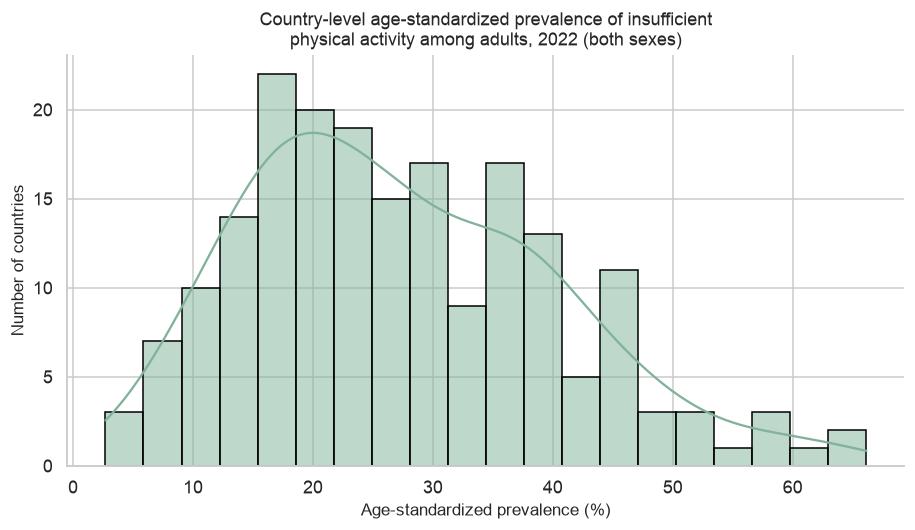

In [61]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(
    data=df_country_2022_both,
    x="prevalence",
    bins=20,
    kde=True,
    color=PALETTE_SEX["Both sexes"],
    edgecolor="black",
    ax=ax,
)
ax.set_title(
    "Country-level age-standardized prevalence of insufficient\n"
    "physical activity among adults, 2022 (both sexes)"
)
ax.set_xlabel("Age-standardized prevalence (%)")
ax.set_ylabel("Number of countries")
fig.tight_layout()
save_figure("01_country_distribution_2022.png")
plt.show()


The 2022 distribution is right-skewed: many countries cluster between about 15% and 35%, with a smaller set of countries above 50%. Because each country appears once, high-prevalence countries are not repeated across years.


## 7. Differences by sex in 2022

**Figure 2.** Country-level male and female estimates in 2022. *N* = 195 countries × 2 = 390 observations. `Both sexes` is excluded.


Saved figures/02_distribution_by_sex_2022.png


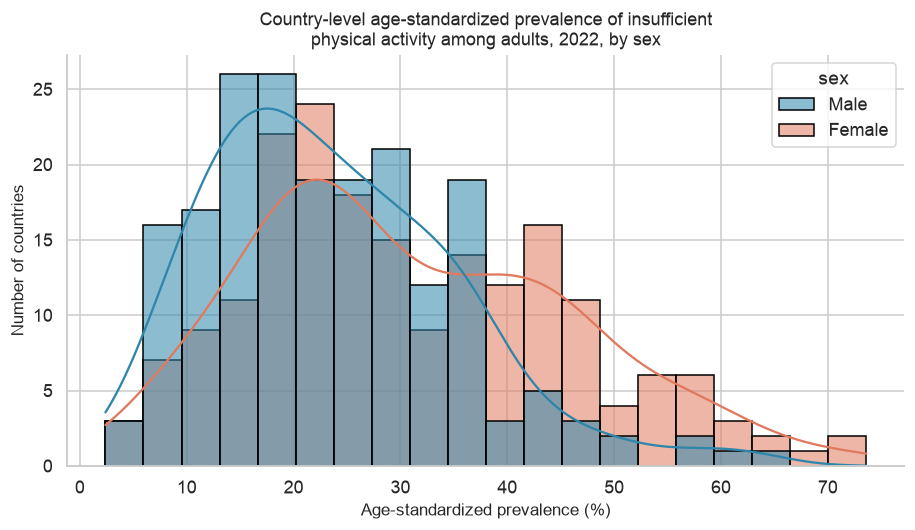

In [62]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(
    data=df_country_2022_sex,
    x="prevalence",
    hue="sex",
    hue_order=["Male", "Female"],
    bins=20,
    kde=True,
    multiple="layer",
    palette={"Male": PALETTE_SEX["Male"], "Female": PALETTE_SEX["Female"]},
    alpha=0.55,
    edgecolor="black",
    ax=ax,
)
ax.set_title(
    "Country-level age-standardized prevalence of insufficient\n"
    "physical activity among adults, 2022, by sex"
)
ax.set_xlabel("Age-standardized prevalence (%)")
ax.set_ylabel("Number of countries")
fig.tight_layout()
save_figure("02_distribution_by_sex_2022.png")
plt.show()


Female estimates sit further to the right than male estimates. The gap is a descriptive pattern in the 2022 cross-section, not a test of a causal sex effect.


## 8. Differences across WHO regions in 2022

**Figure 3.** Country-level both-sexes estimates in 2022, grouped by WHO region. Outliers are **countries**, not country-years.


Saved figures/03_distribution_by_who_region_2022.png


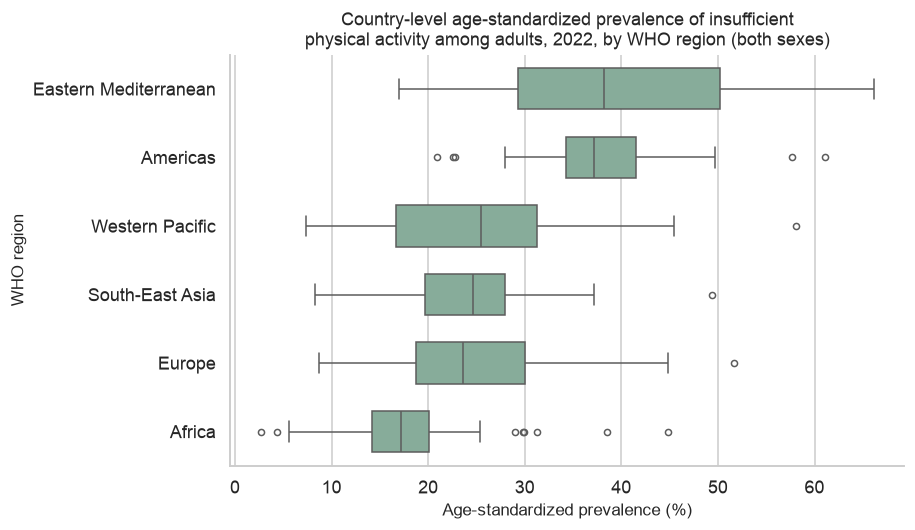

In [63]:
region_order = (
    df_country_2022_both.groupby("region")["prevalence"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.boxplot(
    data=df_country_2022_both,
    y="region",
    x="prevalence",
    order=region_order,
    color=PALETTE_SEX["Both sexes"],
    width=0.6,
    fliersize=4,
    linewidth=1,
    ax=ax,
)
ax.set_title(
    "Country-level age-standardized prevalence of insufficient\n"
    "physical activity among adults, 2022, by WHO region (both sexes)"
)
ax.set_xlabel("Age-standardized prevalence (%)")
ax.set_ylabel("WHO region")
fig.tight_layout()
save_figure("03_distribution_by_who_region_2022.png")
plt.show()


In [64]:
iqr_by_region_2022 = (
    df_country_2022_both.groupby("region")["prevalence"]
    .agg(
        n_countries="size",
        median="median",
        Q1=lambda s: s.quantile(0.25),
        Q3=lambda s: s.quantile(0.75),
    )
)
iqr_by_region_2022["IQR"] = iqr_by_region_2022["Q3"] - iqr_by_region_2022["Q1"]
iqr_by_region_2022.round(2).sort_values("IQR", ascending=False)


,n_countries,median,Q1,Q3,IQR
region,,,,,
Eastern Mediterranean,22,38.23,29.32,50.22,20.90
Western Pacific,27,25.42,16.65,31.28,14.63
Europe,52,23.64,18.76,30.00,11.24
South-East Asia,11,24.62,19.65,27.93,8.28
Americas,36,37.17,34.28,41.53,7.24
Africa,47,17.20,14.18,20.06,5.88


Within-region spread is largest in the Eastern Mediterranean and Western Pacific. A wide IQR means member countries differ substantially from one another in 2022; it is not a confidence interval for a regional mean.


## 9. Spatial patterns in 2022

World maps use **Natural Earth 110m Admin 0 – Countries** (public domain, v5.1.1), joined to WHO country codes on ISO 3166-1 alpha-3 via `ISO_A3_EH`. France and Norway are `-99` in `ISO_A3`, so that field is not used. No geometries are invented for countries that this scale omits.

The 2022 analytical dataset has WHO estimates for **195** countries. Natural Earth 110m provides a usable polygon for **167** of them. The remaining 28 are small states and island countries omitted by 110m cartographic generalization. They stay in every statistical table; they simply cannot be drawn as polygons. Grey areas on the maps are a different case: Natural Earth polygons with no matching WHO country estimate.

Values are WHO **age-standardized modeled estimates**, not crude survey prevalence.


### Country-level prevalence

**Figure 5.** Age-standardized prevalence of insufficient physical activity among adults, 2022 — both sexes.


Map coverage: 167 of 195 WHO countries have a Natural Earth 110m polygon; 28 do not (listed in the join audit below).
Saved figures/05_world_prevalence_2022.png


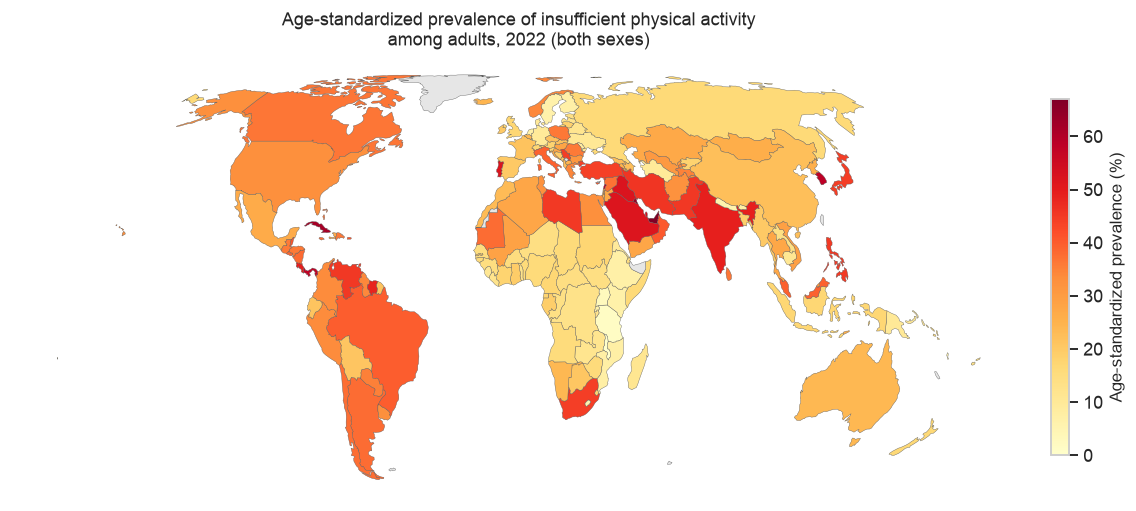

In [65]:
world = gpd.read_file(NE_COUNTRIES)
world["iso3"] = world["ISO_A3_EH"].where(world["ISO_A3_EH"] != "-99")
valid_geom = world.dropna(subset=["iso3"])
assert valid_geom["iso3"].is_unique, "Duplicate ISO_A3_EH codes in Natural Earth 110m"

name_src = pd.read_csv(COUNTRY_CSV)[["SpatialDimValueCode", "Location"]].drop_duplicates()
who_iso3 = df_country_2022_both["country_code"]
names_195 = name_src.loc[name_src["SpatialDimValueCode"].isin(who_iso3)].copy()
assert names_195["SpatialDimValueCode"].is_unique
assert names_195["SpatialDimValueCode"].nunique() == who_iso3.nunique() == 195
missing_names = sorted(set(who_iso3) - set(names_195["SpatialDimValueCode"]))
assert not missing_names, f"Missing country names: {missing_names}"
country_names = dict(zip(names_195["SpatialDimValueCode"], names_195["Location"]))

matched_iso = set(who_iso3) & set(valid_geom["iso3"])
unmatched_who = sorted(set(who_iso3) - set(valid_geom["iso3"]))
unmatched_geom = sorted(set(valid_geom["iso3"]) - set(who_iso3))
print(
    f"Map coverage: {len(matched_iso)} of {who_iso3.nunique()} WHO countries "
    f"have a Natural Earth 110m polygon; {len(unmatched_who)} do not "
    "(listed in the join audit below)."
)

MISSING_FILL = "#e6e6e6"
BOUNDARY_KW = dict(edgecolor="#5b5b5b", linewidth=0.25)
MAP_CRS = "+proj=eqearth"


def plot_world_choropleth(
    gdf,
    column,
    *,
    cmap,
    vmin,
    vmax,
    cbar_label,
    title,
    filename,
    norm=None,
    subtitle=None,
    cbar_low_label=None,
    cbar_high_label=None,
):
    # Equal Earth world map; Antarctica omitted for layout.
    plot_gdf = gdf.loc[gdf["ADM0_A3"] != "ATA"].to_crs(MAP_CRS)
    fig, ax = plt.subplots(figsize=(11.5, 5.6))
    plot_gdf.plot(
        ax=ax,
        column=column,
        cmap=cmap,
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
        norm=norm,
        missing_kwds={
            "color": MISSING_FILL,
            "edgecolor": BOUNDARY_KW["edgecolor"],
            "linewidth": BOUNDARY_KW["linewidth"],
        },
        legend=True,
        legend_kwds={"label": cbar_label, "shrink": 0.62, "pad": 0.02},
        **BOUNDARY_KW,
    )
    ax.set_axis_off()
    if subtitle:
        ax.set_title(title, fontsize=13, pad=18)
        ax.text(
            0.5,
            1.0,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=9,
            color="#4a4a4a",
        )
    else:
        ax.set_title(title)
    if cbar_low_label or cbar_high_label:
        cax = fig.axes[-1]
        if cbar_high_label:
            cax.text(
                0.5,
                1.03,
                cbar_high_label,
                transform=cax.transAxes,
                ha="center",
                va="bottom",
                fontsize=8,
            )
        if cbar_low_label:
            cax.text(
                0.5,
                -0.03,
                cbar_low_label,
                transform=cax.transAxes,
                ha="center",
                va="top",
                fontsize=8,
            )
    fig.tight_layout()
    save_figure(filename)
    plt.show()


world_prevalence = world.merge(
    df_country_2022_both[["country_code", "prevalence"]],
    left_on="iso3",
    right_on="country_code",
    how="left",
)
prev_max = math.ceil(df_country_2022_both["prevalence"].max())

plot_world_choropleth(
    world_prevalence,
    "prevalence",
    cmap="YlOrRd",
    vmin=0,
    vmax=prev_max,
    cbar_label="Age-standardized prevalence (%)",
    title=(
        "Age-standardized prevalence of insufficient physical activity\n"
        "among adults, 2022 (both sexes)"
    ),
    filename="05_world_prevalence_2022.png",
)


The map shows substantial geographic variation in country-level estimates for 2022. Higher prevalence is visible in parts of the Eastern Mediterranean and the Americas, while many African countries are toward the lower end of the scale. These values are modeled national estimates and the map does not explain the causes of differences between countries.

WHO estimates are available for all 195 countries included in the analysis. However, 28 small states and island countries cannot be displayed because Natural Earth 110m does not provide polygons for them. Their WHO estimates remain included in the statistical analyses and tables. Some additional areas appear grey because Natural Earth provides a polygon for them but there is no corresponding country observation in this WHO dataset.


### Female–male difference

The sex gap is the **percentage-point** difference between the 2022 female and male country-level estimates:

`sex_gap_pp = Female − Male`

Positive values: the female estimate is higher. Negative values: the male estimate is higher. This is a descriptive comparison of two WHO age-standardized modeled estimates, not a percent change and not a hypothesis test. Separate male and female 95% confidence intervals are not combined into an interval for Female − Male.


In [66]:
sex_2022 = df_country_2022_sex.copy()
counts = sex_2022.groupby(["country_code", "sex"]).size()
assert (counts == 1).all(), "Expected exactly one row per country × sex in 2022"
assert sex_2022.duplicated(subset=["country_code", "sex", "year"]).sum() == 0

n_female = sex_2022.loc[sex_2022["sex"] == "Female", "country_code"].nunique()
n_male = sex_2022.loc[sex_2022["sex"] == "Male", "country_code"].nunique()
assert n_female == n_male == df_country_2022_both["country_code"].nunique() == 195

sex_wide = (
    sex_2022.pivot(index="country_code", columns="sex", values="prevalence")
    .rename(columns={"Female": "female_prevalence", "Male": "male_prevalence"})
)
assert sex_wide[["female_prevalence", "male_prevalence"]].notna().all().all()

sex_wide["sex_gap_pp"] = sex_wide["female_prevalence"] - sex_wide["male_prevalence"]
sex_wide["country_name"] = sex_wide.index.map(country_names)
sex_wide = sex_wide.reset_index()
sex_wide.columns.name = None
sex_wide["on_110m_map"] = sex_wide["country_code"].map(
    lambda code: "Yes" if code in matched_iso else "No"
)
assert sex_wide["country_name"].notna().all()
assert (sex_wide["on_110m_map"] == "Yes").sum() == len(matched_iso)
assert (sex_wide["on_110m_map"] == "No").sum() == len(unmatched_who)

gap = sex_wide["sex_gap_pp"]
n_pos = int((gap > 0).sum())
n_neg = int((gap < 0).sum())
n_zero = int((gap == 0).sum())
gap_limit = math.ceil(max(abs(gap.min()), abs(gap.max())) * 2) / 2

print(f"Countries: {len(sex_wide)} (complete 2022 WHO set, not only mapped countries)")
print(f"Mean {gap.mean():.2f} pp; median {gap.median():.2f} pp")
print(f"Minimum {gap.min():.2f} pp; maximum {gap.max():.2f} pp")
print(f"Female estimate higher: {n_pos}")
print(f"Male estimate higher: {n_neg}")
print(f"Equal estimates: {n_zero}")
print(f"Symmetric colorbar limits: ±{gap_limit:.1f} percentage points")


Countries: 195 (complete 2022 WHO set, not only mapped countries)
Mean 7.41 pp; median 6.49 pp
Minimum -8.45 pp; maximum 26.01 pp
Female estimate higher: 169
Male estimate higher: 26
Equal estimates: 0
Symmetric colorbar limits: ±26.5 percentage points


**Figure 6.** Sex gap in insufficient physical activity, 2022.


Saved figures/06_world_sex_gap_2022.png


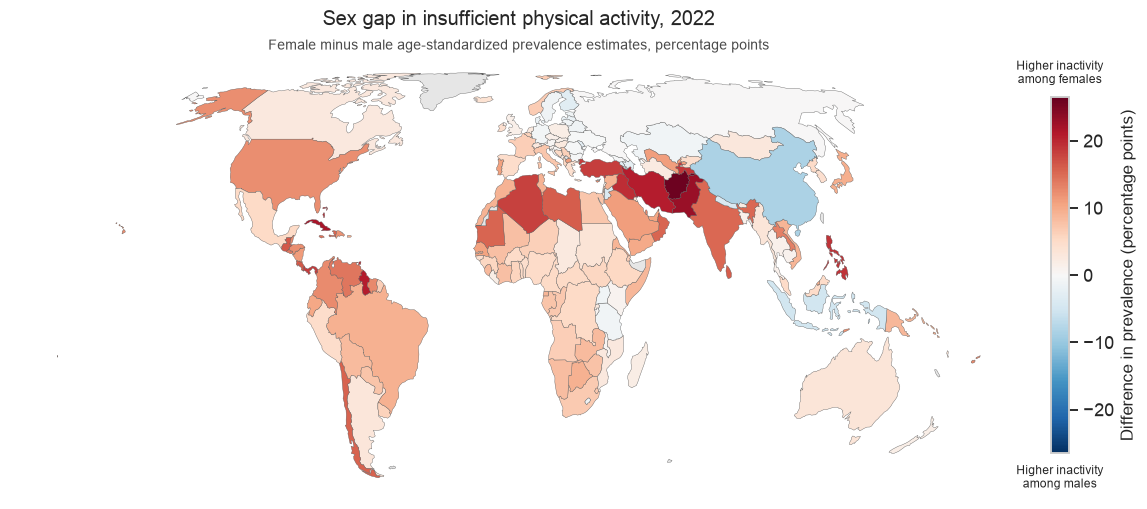

In [67]:
world_gap = world.merge(
    sex_wide[["country_code", "sex_gap_pp"]],
    left_on="iso3",
    right_on="country_code",
    how="left",
)

gap_norm = TwoSlopeNorm(vmin=-gap_limit, vcenter=0, vmax=gap_limit)
plot_world_choropleth(
    world_gap,
    "sex_gap_pp",
    cmap="RdBu_r",
    vmin=-gap_limit,
    vmax=gap_limit,
    norm=gap_norm,
    cbar_label="Difference in prevalence (percentage points)",
    title="Sex gap in insufficient physical activity, 2022",
    subtitle="Female minus male age-standardized prevalence estimates, percentage points",
    cbar_low_label="Higher inactivity\namong males",
    cbar_high_label="Higher inactivity\namong females",
    filename="06_world_sex_gap_2022.png",
)


Positive values indicate higher estimated prevalence of insufficient physical activity among females; negative values indicate higher prevalence among males. The difference is measured in percentage points.

These are WHO age-standardized modeled estimates. The map is descriptive: it is not a statistical significance test, and separate male and female confidence intervals are not combined into an interval for Female − Male. The analysis does not identify causes of geographic sex differences. Grey polygons are Natural Earth units with no matching WHO country estimate. WHO countries without a 110m polygon are omitted from the drawing, not from the ranking below.


### Countries with the largest sex differences

Rankings use all **195** WHO countries, including those without a Natural Earth 110m polygon. `On 110m map` is derived from the geometry join (`Yes` / `No`). Difference = Female − Male, in percentage points.


In [ ]:
RANK_COLS = [
    "country_name",
    "female_prevalence",
    "male_prevalence",
    "sex_gap_pp",
    "on_110m_map",
]
RANK_RENAME = {
    "country_name": "Country",
    "female_prevalence": "Female (%)",
    "male_prevalence": "Male (%)",
    "sex_gap_pp": "Difference (pp)",
    "on_110m_map": "On 110m map",
}


def ranked_gap_table(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame[RANK_COLS].round(2).rename(columns=RANK_RENAME).reset_index(drop=True)
    out.insert(0, "Rank", range(1, len(out) + 1))
    return out


table_a = ranked_gap_table(sex_wide.nlargest(10, "sex_gap_pp"))
table_b = ranked_gap_table(
    sex_wide.loc[sex_wide["sex_gap_pp"] < 0].nsmallest(10, "sex_gap_pp")
)

print("Table A. Largest female-over-male differences (all 195 WHO countries)")
display(table_a)
print("Not drawn on the 110m choropleth:", ", ".join(table_a.loc[table_a["On 110m map"] == "No", "Country"]) or "none")

print("\nTable B. Largest male-over-female differences (sex_gap_pp < 0; all 195 WHO countries)")
display(table_b)
print("Not drawn on the 110m choropleth:", ", ".join(table_b.loc[table_b["On 110m map"] == "No", "Country"]) or "none")


Table A. Largest female-over-male differences (all 195 WHO countries)


,Rank,Country,Female (%),Male (%),Difference (pp),On 110m map
0,1,Afghanistan,46.03,20.02,26.01,Yes
1,2,Pakistan,57.01,34.14,22.87,Yes
2,3,Cuba,72.03,50.25,21.78,Yes
3,4,Guyana,45.07,24.21,20.85,Yes
4,5,Iran (Islamic Republic of),56.65,35.91,20.73,Yes
5,6,Bahamas,46.62,26.57,20.05,Yes
6,7,Kiribati,41.14,21.24,19.90,No
7,8,Iraq,61.51,41.89,19.62,Yes
8,9,Trinidad and Tobago,54.17,34.63,19.53,Yes
9,10,Palau,35.97,16.58,19.39,No


Not drawn on the 110m choropleth: Kiribati, Palau

Table B. Largest male-over-female differences (sex_gap_pp < 0; all 195 WHO countries)


,Rank,Country,Female (%),Male (%),Difference (pp),On 110m map
0,1,China,19.50,27.95,-8.45,Yes
1,2,Indonesia,16.42,21.51,-5.09,Yes
2,3,Nepal,6.35,10.45,-4.10,Yes
3,4,Jordan,26.12,30.02,-3.91,Yes
4,5,Finland,8.08,11.06,-2.98,Yes
5,6,Armenia,25.31,28.25,-2.93,Yes
6,7,Republic of Moldova,9.62,12.12,-2.50,Yes
7,8,Azerbaijan,22.81,25.08,-2.26,Yes
8,9,Singapore,22.05,24.16,-2.11,No
9,10,Denmark,11.21,13.06,-1.85,Yes


Not drawn on the 110m choropleth: Singapore


### Geographic coverage and join audit

The choropleth is a geographic view of the 2022 WHO country dataset, not a complete census of that dataset. Unmatched WHO countries are listed here rather than dropped.


In [ ]:
print(f"WHO countries in the 2022 analytical subset: {who_iso3.nunique()}")
print(f"Matched Natural Earth 110m country codes: {len(matched_iso)}")
print(f"Unmatched WHO countries (no 110m polygon): {len(unmatched_who)}")
print("Join field: ISO_A3_EH. Duplicate 110m ISO-3 codes:", int(valid_geom["iso3"].duplicated().sum()))

unmatched_who_tbl = pd.DataFrame({
    "ISO-3": unmatched_who,
    "Country": [country_names[c] for c in unmatched_who],
})
print("\nWHO countries omitted from the choropleth because Natural Earth 110m has no polygon:")
display(unmatched_who_tbl)

print("Natural Earth ISO-3 polygons without a WHO country-level 2022 estimate (grey on the map):")
print(", ".join(unmatched_geom) if unmatched_geom else "(none)")


WHO countries in the 2022 analytical subset: 195
Matched Natural Earth 110m country codes: 167
Unmatched WHO countries (no 110m polygon): 28
Join field: ISO_A3_EH. Duplicate 110m ISO-3 codes: 0

WHO countries omitted from the choropleth because Natural Earth 110m has no polygon:


,ISO-3,Country
0,AND,Andorra
1,ATG,Antigua and Barbuda
2,BHR,Bahrain
3,BRB,Barbados
4,COK,Cook Islands
5,COM,Comoros
6,CPV,Cabo Verde
7,DMA,Dominica
8,FSM,Micronesia (Federated States of)
9,GRD,Grenada


Natural Earth ISO-3 polygons without a WHO country-level 2022 estimate (grey on the map):
ATA, ATF, ESH, FLK, GRL, NCL, TWN


These 28 countries have complete 2022 WHO estimates. Their absence from the map is a Natural Earth 110m generalization limit, not missing health data. Grey polygons (Greenland, Taiwan, Antarctica, and similar) are the reverse: geometries with no matching WHO country estimate.


## 10. WHO global trend, 2000–2022

**Figure 4.** Official GHO **global** series (`spatial_type == "Global"`, both sexes), one estimate per year. This is not an unweighted average of the 195 country rows. The y-axis is restricted to the range of the estimates and 95% confidence intervals so year-to-year change is visible; it does **not** start at zero.

Shaded bands are the WHO 95% confidence intervals around each annual estimate. They describe uncertainty in the modeled global series, not a hypothesis test.


Saved figures/04_global_trend_2000_2022.png


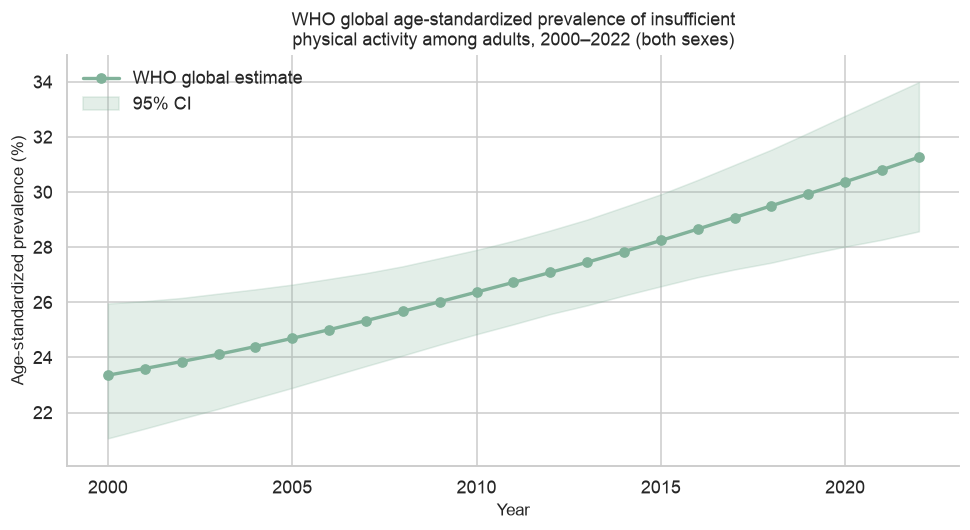

Y-axis limits: 20.1 to 35.0 (restricted; not starting at 0)


,year,prevalence,ci_low,ci_high
13086,2000,23.36,21.06,25.96
13452,2022,31.27,28.58,33.99


In [70]:
y_min = df_global_both["ci_low"].min() - 1
y_max = df_global_both["ci_high"].max() + 1

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(
    df_global_both["year"],
    df_global_both["prevalence"],
    color=PALETTE_SEX["Both sexes"],
    marker="o",
    linewidth=2.2,
    label="WHO global estimate",
)
ax.fill_between(
    df_global_both["year"],
    df_global_both["ci_low"],
    df_global_both["ci_high"],
    color=PALETTE_SEX["Both sexes"],
    alpha=0.22,
    label="95% CI",
)
ax.set_ylim(y_min, y_max)
ax.set_title(
    "WHO global age-standardized prevalence of insufficient\n"
    "physical activity among adults, 2000–2022 (both sexes)"
)
ax.set_xlabel("Year")
ax.set_ylabel("Age-standardized prevalence (%)")
ax.legend(frameon=False)
fig.tight_layout()
save_figure("04_global_trend_2000_2022.png")
plt.show()

print(f"Y-axis limits: {y_min:.1f} to {y_max:.1f} (restricted; not starting at 0)")
display(
    df_global_both.loc[
        df_global_both["year"].isin([2000, 2022]),
        ["year", "prevalence", "ci_low", "ci_high"],
    ].round(2)
)


The WHO global estimate rose from about **23.4%** in 2000 to about **31.3%** in 2022. The 2022 WHO global point estimate (31.3%) is higher than the unweighted mean across countries (27.3%). These measures are not directly comparable: the country mean gives each country equal weight, whereas the WHO global estimate is a separately modeled population-level estimate. Interval overlap from year to year is not treated here as a formal significance test.


## 11. Key findings and limitations

**Findings (descriptive)**

- In 2022, country-level both-sexes estimates were typically in the mid-20% range, with large cross-country variation.
- Female country-level prevalence was higher than male prevalence in most countries in the 2022 cross-section.
- Eastern Mediterranean and American countries had the highest unweighted regional means; African countries had the lowest.
- Mapped 2022 prevalence is highest in parts of the Eastern Mediterranean, the Americas, and some Pacific and Asian countries, and lower across much of Africa (among countries with a Natural Earth 110m polygon).
- The female–male gap is a percentage-point difference between two modeled estimates, not a statistical test.
- The WHO global series increased over 2000–2022.

**Limitations**

- Figures are modeled WHO GHO estimates, not raw survey microdata.
- Estimates are **age-standardized** and are not crude prevalence.
- Country tables, distribution plots, and maps of country values are **unweighted** and are not equivalent to the WHO global population-level estimate.
- Natural Earth 110m omits many small island states and some territories; those WHO countries are documented in the join audit rather than drawn.
- The female–male map does not include an uncertainty interval for the difference.
- 2022 is the latest year in this pinned dataset.
- Cross-country and sex differences are descriptive; they do not identify causes.


## 12. Figure export

Figures are written to `figures/` when the plot cells above are run (300 dpi PNG):

- `01_country_distribution_2022.png`
- `02_distribution_by_sex_2022.png`
- `03_distribution_by_who_region_2022.png`
- `04_global_trend_2000_2022.png`
- `05_world_prevalence_2022.png`
- `06_world_sex_gap_2022.png`


## 13. Environment


In [71]:
print(f"Python {sys.version.split()[0]}")
print(f"pandas {pd.__version__}")
print(f"geopandas {gpd.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print(f"seaborn {sns.__version__}")


Python 3.11.15
pandas 3.0.5
geopandas 1.1.4
matplotlib 3.11.1
seaborn 0.13.2
